# Gold — Volume de Procedimentos x Contexto Socioeconômico (Brasil, por ano)

Constrói a camada **Gold** cruzando o volume de procedimentos ISAPS do Brasil (2018-2024) com o contexto socioeconômico do IBGE — escolaridade, população e renda — no mesmo ano.

**Ressalva aqui:** isso é uma sobreposição temporal (ano contra ano, agregado nacional contra agregado nacional, 7 pontos no tempo), não uma correlação estatística validada nem uma relação causal. É útil para visualizar tendências andando juntas (ou não), não para afirmar que uma explica a outra.

## 1. Imports e configuração

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from minio import Minio
from sqlalchemy import create_engine, text

In [2]:
load_dotenv(Path.cwd().parent / ".env")

MINIO_ENDPOINT = os.getenv("MINIO_ENDPOINT", "localhost:9000")
MINIO_ACCESS_KEY = os.getenv("MINIO_ACCESS_KEY")
MINIO_SECRET_KEY = os.getenv("MINIO_SECRET_KEY")

BUCKET_SILVER = os.getenv("BUCKET_SILVER", "silver")
ISAPS_PREFIX = "procedures_by_country/"
IBGE_PREFIX = "dados_IBGE/"

BUCKET_GOLD = os.getenv("BUCKET_GOLD", "gold")
GOLD_PREFIX = "contexto_brasil/"

GOLD_DIR = Path.cwd().parent / "dados_processados" / "gold" / "contexto_brasil"
GOLD_DIR.mkdir(parents=True, exist_ok=True)

client = Minio(MINIO_ENDPOINT, access_key=MINIO_ACCESS_KEY, secret_key=MINIO_SECRET_KEY, secure=False)
if not client.bucket_exists(BUCKET_GOLD):
    client.make_bucket(BUCKET_GOLD)
    print(f"Bucket '{BUCKET_GOLD}' criado.")

PG_DATA_USER = os.getenv("PG_DATA_USER", "postgres")
PG_DATA_PASSWORD = os.getenv("PG_DATA_PASSWORD", "postgres")
PG_DATA_DB = os.getenv("PG_DATA_DB", "projeto-ai")
PG_DATA_HOST = os.getenv("PG_DATA_HOST", "localhost")
PG_DATA_PORT = os.getenv("PG_DATA_PORT", "5434")
PG_SCHEMA = "gold"

engine = create_engine(f"postgresql+psycopg2://{PG_DATA_USER}:{PG_DATA_PASSWORD}@{PG_DATA_HOST}:{PG_DATA_PORT}/{PG_DATA_DB}")
with engine.begin() as conn:
    conn.execute(text(f"CREATE SCHEMA IF NOT EXISTS {PG_SCHEMA}"))

print(f"MinIO: {MINIO_ENDPOINT} | bucket silver: {BUCKET_SILVER} | bucket gold: {BUCKET_GOLD}")
print(f"Postgres: {PG_DATA_HOST}:{PG_DATA_PORT}/{PG_DATA_DB} | schema: {PG_SCHEMA}")
print(f"Saida parquet local: {GOLD_DIR}")

MinIO: localhost:9000 | bucket silver: silver | bucket gold: gold
Postgres: localhost:5434/projeto-ai | schema: gold
Saida parquet local: C:\Projeto_AI\dados_processados\gold\contexto_brasil


## 2. Carregamento da Silver (ISAPS + IBGE)

In [3]:
def ler_parquet_silver(prefixo, nome_arquivo):
    data = client.get_object(BUCKET_SILVER, f"{prefixo}{nome_arquivo}").read()
    return pd.read_parquet(pd.io.common.BytesIO(data))


objetos_isaps = list(client.list_objects(BUCKET_SILVER, prefix=ISAPS_PREFIX, recursive=True))
isaps = pd.concat(
    [pd.read_parquet(pd.io.common.BytesIO(client.get_object(BUCKET_SILVER, obj.object_name).read())) for obj in objetos_isaps],
    ignore_index=True,
)

populacao = ler_parquet_silver(IBGE_PREFIX, "populacao.parquet")
escolaridade = ler_parquet_silver(IBGE_PREFIX, "escolaridade.parquet")
renda = ler_parquet_silver(IBGE_PREFIX, "renda.parquet")

for nome, df in [("isaps", isaps), ("populacao", populacao), ("escolaridade", escolaridade), ("renda", renda)]:
    print(f"{nome}: {df.shape}")

isaps: (5382, 9)
populacao: (14, 6)
escolaridade: (98, 6)
renda: (20, 6)


## 3. Volume de procedimentos do Brasil, por ano — mesma regra já validada

Mesma lógica de [gold_volume_brasil_vs_paises_isaps.ipynb](gold_volume_brasil_vs_paises_isaps.ipynb): o volume total por ano vem da soma dos dois totais já agregados pelo ISAPS (`Total Surgical Procedures` + as 3 grafias de `Total Non-Surgical...`), nunca das linhas individuais/subtotais de categoria — evita contar cada procedimento em dobro. Aqui filtrado só para `BRAZIL`.

In [4]:
ROTULO_TOTAL_CIRURGICO = {"Total Surgical Procedures"}
ROTULOS_TOTAL_NAO_CIRURGICO = {"Total Non-Surgical", "Total Non-Surgical Procedures", "Total Nonsurgical Procedures"}

brasil = isaps[isaps["pais"] == "BRAZIL"]

total_cirurgico = brasil[
    (brasil["tipo_procedimento"] == "CIRURGICO") & (brasil["procedimento"].isin(ROTULO_TOTAL_CIRURGICO))
][["ano_referencia", "quantidade"]].rename(columns={"quantidade": "quantidade_cirurgico"})

total_nao_cirurgico = brasil[
    (brasil["tipo_procedimento"] == "NAO-CIRURGICO") & (brasil["procedimento"].isin(ROTULOS_TOTAL_NAO_CIRURGICO))
][["ano_referencia", "quantidade"]].rename(columns={"quantidade": "quantidade_nao_cirurgico"})

volume_brasil = pd.merge(total_cirurgico, total_nao_cirurgico, on="ano_referencia", how="inner")
volume_brasil["quantidade_total"] = volume_brasil["quantidade_cirurgico"] + volume_brasil["quantidade_nao_cirurgico"]
volume_brasil = volume_brasil.rename(columns={"ano_referencia": "ano"}).sort_values("ano").reset_index(drop=True)

assert len(volume_brasil) == brasil["ano_referencia"].nunique(), "Faltando ano no volume do Brasil"
volume_brasil

,ano,quantidade_cirurgico,quantidade_nao_cirurgico,quantidade_total
0,2018,1498327.0,769078.0,2267405.0
1,2019,1493673.0,1072002.0,2565675.0
2,2020,1306962.0,622396.0,1929358.0
3,2021,1634220.0,1089420.0,2723640.0
4,2022,2049257.0,971294.0,3020551.0
5,2023,2185038.0,1196513.0,3381551.0
6,2024,2354513.0,769245.0,3123758.0


## 4. Contexto socioeconômico do Brasil, por ano

Três indicadores resumidos na granularidade de ano (sem quebra por sexo, que é o nível que os gráficos desta Gold precisam):

- **`populacao_total_mil`**: soma de Homens + Mulheres (`populacao`, já é só a linha `Total` de `grupo_idade`).
- **`escolaridade_superior_pct`**: percentual de pessoas com "Superior completo" sobre o total de `escolaridade` (que cobre pessoas de 14 anos ou mais, não a população total).
- **`renda_media_reais`**: média simples entre a renda de Homens e Mulheres (não ponderada pela população de cada grupo — mesma simplificação já assumida na Gold do DATASUS).

Os nulos que aparecerem (`escolaridade`/`população` não têm 2020 e 2021; `renda` não tem 2021) são as mesmas lacunas já documentadas na Silver do IBGE — não são preenchidos aqui.

In [5]:
populacao_total_ano = populacao.groupby("ano")["quantidade_mil_pessoas"].sum().rename("populacao_total_mil")

total_escolaridade_ano = escolaridade.groupby("ano")["quantidade_mil_pessoas"].sum()
superior_ano = (
    escolaridade[escolaridade["nivel_instrucao"] == "Superior completo"]
    .groupby("ano")["quantidade_mil_pessoas"].sum()
)
escolaridade_superior_pct = (superior_ano / total_escolaridade_ano * 100).round(1).rename("escolaridade_superior_pct")

renda_media_ano = renda.groupby("ano")["valor_reais"].mean().round(2).rename("renda_media_reais")

contexto_socioeconomico_brasil = pd.concat(
    [populacao_total_ano, escolaridade_superior_pct, renda_media_ano], axis=1
).reset_index()

contexto_socioeconomico_brasil

,ano,populacao_total_mil,escolaridade_superior_pct,renda_media_reais
0,2016,203034.0,12.4,3281.38
1,2017,204358.0,12.8,3329.00
2,2018,205615.0,13.5,3376.88
3,2019,206809.0,14.3,3404.25
4,2022,210024.0,15.8,3235.00
5,2023,210979.0,16.3,3426.88
6,2024,211882.0,17.1,3588.25
7,2014,NaN,NaN,3283.38
8,2015,NaN,NaN,3271.75
9,2020,NaN,NaN,3650.00


## 5. Tabela fato — `procedimentos_x_contexto_brasil`

Junta o volume de procedimentos com o contexto socioeconômico por `ano`, com `how="left"` a partir dos anos do ISAPS (2018-2024) — se um indicador do IBGE não existir naquele ano, a célula fica nula, não estimada.

In [6]:
procedimentos_x_contexto_brasil = pd.merge(volume_brasil, contexto_socioeconomico_brasil, on="ano", how="left")
procedimentos_x_contexto_brasil

,ano,quantidade_cirurgico,quantidade_nao_cirurgico,quantidade_total,populacao_total_mil,escolaridade_superior_pct,renda_media_reais
0,2018,1498327.0,769078.0,2267405.0,205615.0,13.5,3376.88
1,2019,1493673.0,1072002.0,2565675.0,206809.0,14.3,3404.25
2,2020,1306962.0,622396.0,1929358.0,NaN,NaN,3650.00
3,2021,1634220.0,1089420.0,2723640.0,NaN,NaN,NaN
4,2022,2049257.0,971294.0,3020551.0,210024.0,15.8,3235.00
5,2023,2185038.0,1196513.0,3381551.0,210979.0,16.3,3426.88
6,2024,2354513.0,769245.0,3123758.0,211882.0,17.1,3588.25


## 6. Gravação em Parquet (Gold) e no Postgres

Local (`dados_processados/gold/contexto_brasil/`), MinIO (bucket `gold`) e Postgres (schema `gold`, recriadas a cada execução).

In [7]:
tabelas_gold = {
    "contexto_socioeconomico_brasil": contexto_socioeconomico_brasil,
    "procedimentos_x_contexto_brasil": procedimentos_x_contexto_brasil,
}

arquivos_gerados = {}
for nome, df in tabelas_gold.items():
    out_path = GOLD_DIR / f"{nome}.parquet"
    df.to_parquet(out_path, engine="pyarrow", index=False)
    arquivos_gerados[nome] = out_path

    object_name = f"{GOLD_PREFIX}{nome}.parquet"
    client.fput_object(BUCKET_GOLD, object_name, str(out_path))

    df.to_sql(nome, engine, schema=PG_SCHEMA, if_exists="replace", index=False)

    print(f"Gravado: {out_path} ({len(df)} linhas) -> s3://{BUCKET_GOLD}/{object_name} -> Postgres {PG_SCHEMA}.{nome}")

Gravado: C:\Projeto_AI\dados_processados\gold\contexto_brasil\contexto_socioeconomico_brasil.parquet (10 linhas) -> s3://gold/contexto_brasil/contexto_socioeconomico_brasil.parquet -> Postgres gold.contexto_socioeconomico_brasil


Gravado: C:\Projeto_AI\dados_processados\gold\contexto_brasil\procedimentos_x_contexto_brasil.parquet (7 linhas) -> s3://gold/contexto_brasil/procedimentos_x_contexto_brasil.parquet -> Postgres gold.procedimentos_x_contexto_brasil


## 7. Gráficos

### 7.1 Evolução do volume total de procedimentos no Brasil, por ano (linha)

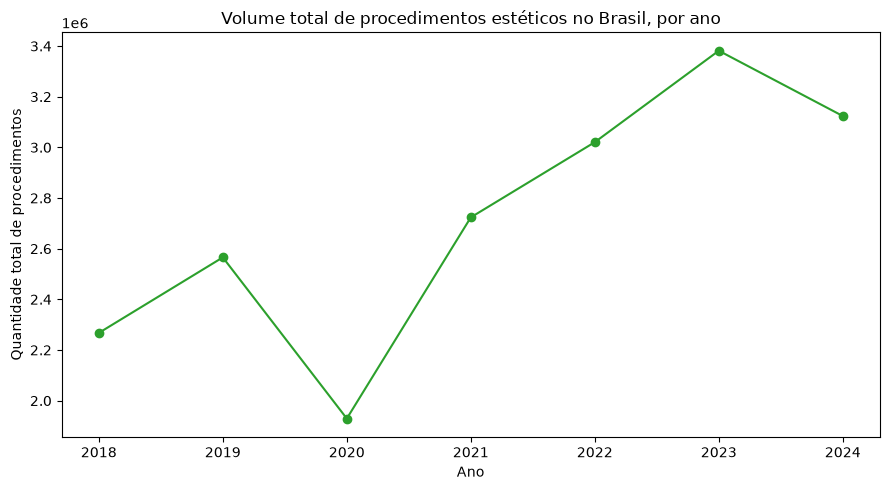

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(procedimentos_x_contexto_brasil["ano"], procedimentos_x_contexto_brasil["quantidade_total"], marker="o", color="tab:green")
ax.set_title("Volume total de procedimentos estéticos no Brasil, por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade total de procedimentos")
plt.tight_layout()
plt.show()

### 7.2 Volume de procedimentos x renda média (eixo duplo)

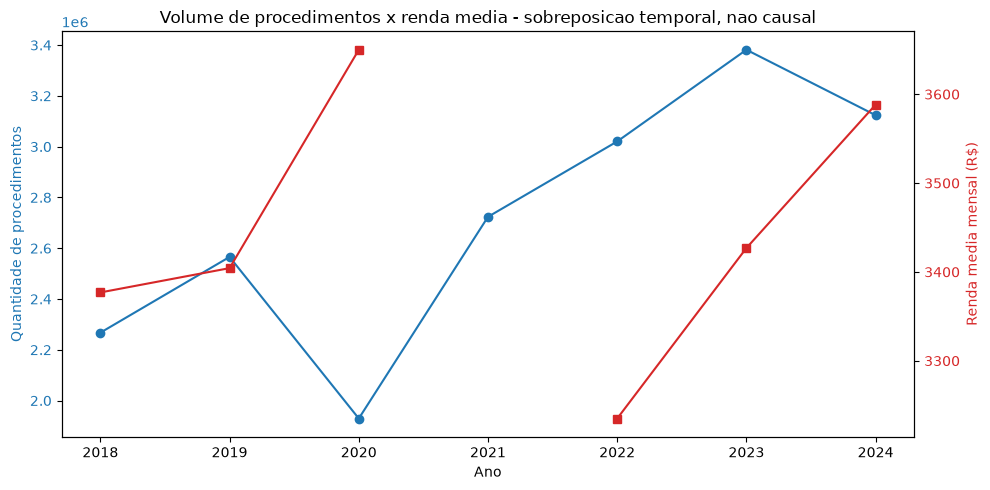

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(procedimentos_x_contexto_brasil["ano"], procedimentos_x_contexto_brasil["quantidade_total"], marker="o", color="tab:blue", label="Volume de procedimentos")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Quantidade de procedimentos", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(procedimentos_x_contexto_brasil["ano"], procedimentos_x_contexto_brasil["renda_media_reais"], marker="s", color="tab:red", label="Renda media (R$)")
ax2.set_ylabel("Renda media mensal (R$)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Volume de procedimentos x renda media - sobreposicao temporal, nao causal")
plt.tight_layout()
plt.show()

### 7.3 Volume de procedimentos x % com ensino superior completo (eixo duplo)

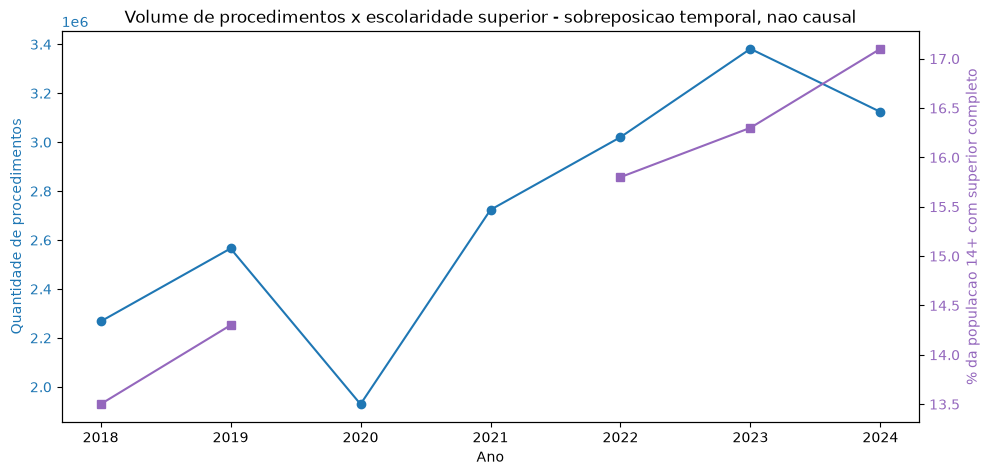

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(procedimentos_x_contexto_brasil["ano"], procedimentos_x_contexto_brasil["quantidade_total"], marker="o", color="tab:blue", label="Volume de procedimentos")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Quantidade de procedimentos", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(procedimentos_x_contexto_brasil["ano"], procedimentos_x_contexto_brasil["escolaridade_superior_pct"], marker="s", color="tab:purple", label="% Superior completo")
ax2.set_ylabel("% da populacao 14+ com superior completo", color="tab:purple")
ax2.tick_params(axis="y", labelcolor="tab:purple")

ax1.set_title("Volume de procedimentos x escolaridade superior - sobreposicao temporal, nao causal")
plt.tight_layout()
plt.show()

### 7.4 Volume de procedimentos x população total (eixo duplo)

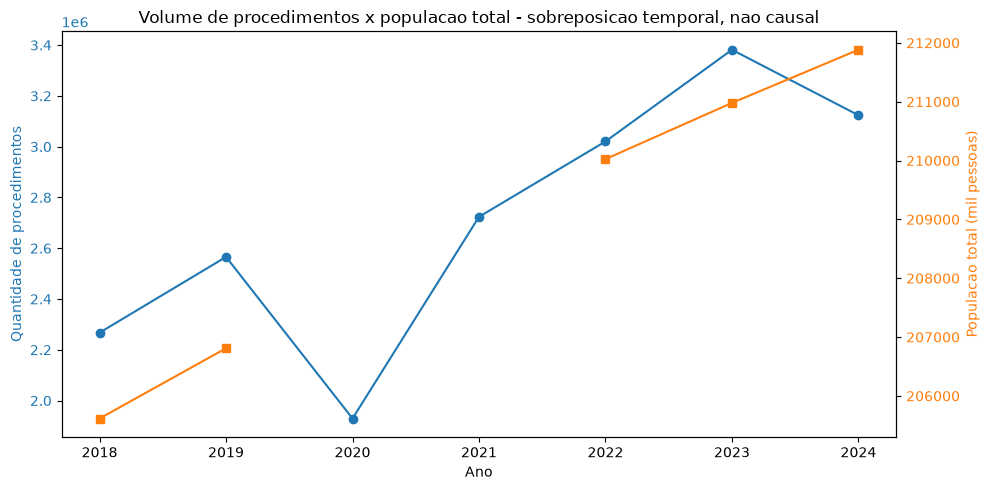

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(procedimentos_x_contexto_brasil["ano"], procedimentos_x_contexto_brasil["quantidade_total"], marker="o", color="tab:blue", label="Volume de procedimentos")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Quantidade de procedimentos", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(procedimentos_x_contexto_brasil["ano"], procedimentos_x_contexto_brasil["populacao_total_mil"], marker="s", color="tab:orange", label="Populacao total (mil)")
ax2.set_ylabel("Populacao total (mil pessoas)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_title("Volume de procedimentos x populacao total - sobreposicao temporal, nao causal")
plt.tight_layout()
plt.show()

## 8. Verificação final no Postgres

Confere direto na fonte: lista as duas tabelas recém-gravadas no schema `gold`, suas contagens de linhas, e o conteúdo completo de `procedimentos_x_contexto_brasil`.

In [12]:
with engine.connect() as conn:
    tabelas_pg = conn.execute(text(
        "SELECT table_name FROM information_schema.tables WHERE table_schema = :schema AND table_name = ANY(:tabelas)"
    ), {"schema": PG_SCHEMA, "tabelas": list(tabelas_gold.keys())}).fetchall()

print(f"Tabelas encontradas no Postgres: {[t[0] for t in tabelas_pg]}")

for nome in tabelas_gold:
    with engine.connect() as conn:
        total = conn.execute(text(f'SELECT COUNT(*) FROM {PG_SCHEMA}."{nome}"')).scalar()
    print(f" - {nome}: {total} linhas")

Tabelas encontradas no Postgres: ['contexto_socioeconomico_brasil', 'procedimentos_x_contexto_brasil']
 - contexto_socioeconomico_brasil: 10 linhas
 - procedimentos_x_contexto_brasil: 7 linhas


In [13]:
with engine.connect() as conn:
    resultado = pd.read_sql(
        text(f'SELECT * FROM {PG_SCHEMA}."procedimentos_x_contexto_brasil" ORDER BY ano'),
        conn,
    )
resultado

,ano,quantidade_cirurgico,quantidade_nao_cirurgico,quantidade_total,populacao_total_mil,escolaridade_superior_pct,renda_media_reais
0,2018,1498327.0,769078.0,2267405.0,205615.0,13.5,3376.88
1,2019,1493673.0,1072002.0,2565675.0,206809.0,14.3,3404.25
2,2020,1306962.0,622396.0,1929358.0,NaN,NaN,3650.00
3,2021,1634220.0,1089420.0,2723640.0,NaN,NaN,NaN
4,2022,2049257.0,971294.0,3020551.0,210024.0,15.8,3235.00
5,2023,2185038.0,1196513.0,3381551.0,210979.0,16.3,3426.88
6,2024,2354513.0,769245.0,3123758.0,211882.0,17.1,3588.25


## 9. Conclusões

- **Volume do Brasil por ano** calculado com a mesma regra já validada na Gold de ranking ISAPS — soma dos totais cirúrgico/não-cirúrgico do próprio ISAPS, sem contar procedimento em dobro.
- **Contexto socioeconômico resumido em 3 indicadores** (população, % superior completo, renda média), na granularidade de ano — os nulos de 2020/2021 (escolaridade/população) e 2021 (renda) permanecem nulos, não foram estimados.
- **Leitura dos gráficos**: sobreposição temporal entre volume de procedimentos e cada indicador — útil para visualizar tendências conjuntas, não para inferir causalidade (n=7 anos, dados agregados nacionais).
- **Publicado em três destinos**, confirmados por leitura direta do Postgres ao final do notebook: Parquet local, MinIO (bucket `gold`) e Postgres (schema `gold`).